<a target="_blank" href="https://colab.research.google.com/github/jvictorferreira3301/metodos-numericos/blob/main/M%C3%A9todos_Num%C3%A9ricos_Grupo_3.ipynb"> <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 1: Raízes de Equações

---

## $I$. Métodos Intervalares

### 1. Varredura de possíveis raízes
* Implementar busca incremental de possíveis raízes num intervalo de interesse, com base na seção 5.4, página 113.
* Receber do usuário a expressão da função, o intervalo de interesse e o número N de subdivisões.
* Calcular o sinal da função para cada subdivisão.
* Retornar os subintervalos com mudança de sinal ou zero da função.
* Retornar gráfico mostrando todas as subdivisões e destacando as detecções de mudança de sinal.
* Solicitar ao usuário se deseja refinar N ou proceder para o cálculo.

MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES

1. ENTRADA DE DADOS
------------------------------------------------------------

2. CÁLCULO DAS SUBDIVISÕES
------------------------------------------------------------

Tabela de Subdivisões:
 Ponto  f(x)    Sinal
   0.0  -4.0 Negativo
   1.0  -3.0 Negativo
   2.0   0.0     Zero
   3.0   5.0 Positivo
   4.0  12.0 Positivo

3. DETECÇÃO DE MUDANÇAS DE SINAL
------------------------------------------------------------

Total de possíveis raízes detectadas: 1

Subintervalos com possíveis raízes:
 Inicio  Fim  f(inicio)  f(fim)            Tipo
    2.0  2.0        0.0     0.0 Zero Encontrado

4. VISUALIZAÇÃO GRÁFICA
------------------------------------------------------------


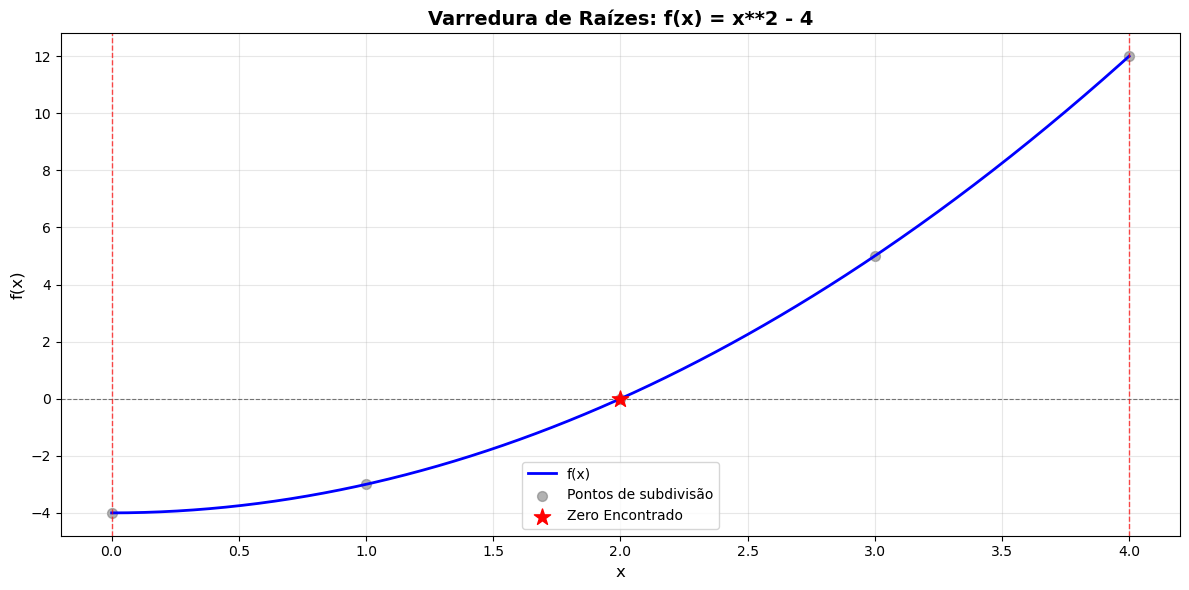


5. REFINAMENTO E PRÓXIMOS PASSOS
------------------------------------------------------------

Opções:
1. Refinar a busca com um novo valor de N
2. Prosseguir para o cálculo de raízes (Método da Bisseção)
3. Sair

Saída do programa.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, sympify
import pandas as pd

def busca_incremental_raizes():
    """
    Implementa a busca incremental de possíveis raízes num intervalo.
    Baseado na seção 5.4, página 113.
    """
    print("="*60)
    print("MÉTODO 1: VARREDURA DE POSSÍVEIS RAÍZES")
    print("="*60)
    
    # Etapa 1: Receber entrada do usuário
    print("\n1. ENTRADA DE DADOS")
    print("-" * 60)
    
    expr_str = input("Insira a expressão da função f(x): ").strip()
    intervalo_1 = float(input("Insira a primeira extremidade do intervalo: "))
    intervalo_2 = float(input("Insira a segunda extremidade do intervalo: "))
    N = int(input("Insira o número N de subdivisões: "))
    
    # Validar intervalo
    if intervalo_1 > intervalo_2:
        intervalo_1, intervalo_2 = intervalo_2, intervalo_1
    
    # Converter string para função
    x = symbols('x')
    try:
        expr = sympify(expr_str)
        f = lambdify(x, expr, 'numpy')
    except:
        print("Erro: Expressão inválida!")
        return None
    
    # Etapa 2: Calcular pontos de subdivisão
    print("\n2. CÁLCULO DAS SUBDIVISÕES")
    print("-" * 60)
    
    pontos = np.linspace(intervalo_1, intervalo_2, N + 1)
    valores_funcao = f(pontos)
    
    # Criar tabela de subdivisões
    dados_subdivisoes = pd.DataFrame({
        'Ponto': pontos,
        'f(x)': valores_funcao,
        'Sinal': ['Positivo' if v > 0 else 'Negativo' if v < 0 else 'Zero' for v in valores_funcao]
    })
    
    print("\nTabela de Subdivisões:")
    print(dados_subdivisoes.to_string(index=False))
    
    # Etapa 3: Detectar mudanças de sinal
    print("\n3. DETECÇÃO DE MUDANÇAS DE SINAL")
    print("-" * 60)
    
    subintervalos_raizes = []
    
    for i in range(len(pontos) - 1):
        # Verificar mudança de sinal
        if valores_funcao[i] * valores_funcao[i+1] < 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i+1],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i+1],
                'Tipo': 'Mudança de Sinal'
            })
        # Verificar zeros exatos
        elif valores_funcao[i] == 0:
            subintervalos_raizes.append({
                'Inicio': pontos[i],
                'Fim': pontos[i],
                'f(inicio)': valores_funcao[i],
                'f(fim)': valores_funcao[i],
                'Tipo': 'Zero Encontrado'
            })
    
    # Verificar último ponto
    if valores_funcao[-1] == 0:
        subintervalos_raizes.append({
            'Inicio': pontos[-1],
            'Fim': pontos[-1],
            'f(inicio)': valores_funcao[-1],
            'f(fim)': valores_funcao[-1],
            'Tipo': 'Zero Encontrado'
        })
    
    print(f"\nTotal de possíveis raízes detectadas: {len(subintervalos_raizes)}")
    
    if subintervalos_raizes:
        df_raizes = pd.DataFrame(subintervalos_raizes)
        print("\nSubintervalos com possíveis raízes:")
        print(df_raizes.to_string(index=False))
    else:
        print("Nenhuma raiz detectada neste intervalo!")
    
    # Etapa 4: Plotar gráfico
    print("\n4. VISUALIZAÇÃO GRÁFICA")
    print("-" * 60)
    
    x_plot = np.linspace(intervalo_1, intervalo_2, 500)
    y_plot = f(x_plot)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plotar a função
    ax.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    
    # Plotar todas as subdivisões
    ax.scatter(pontos, valores_funcao, color='gray', s=50, alpha=0.6, label='Pontos de subdivisão')
    
    # Destacar subdivisões com mudança de sinal
    for raiz in subintervalos_raizes:
        if raiz['Tipo'] == 'Mudança de Sinal':
            ax.axvspan(raiz['Inicio'], raiz['Fim'], alpha=0.3, color='green', label='Mudança de Sinal' if raiz == subintervalos_raizes[0] else '')
            ax.scatter([raiz['Inicio'], raiz['Fim']], [raiz['f(inicio)'], raiz['f(fim)']], 
                      color='green', s=100, marker='o', zorder=5)
        elif raiz['Tipo'] == 'Zero Encontrado':
            ax.scatter([raiz['Inicio']], [raiz['f(inicio)']], 
                      color='red', s=150, marker='*', zorder=5, label='Zero Encontrado' if raiz == subintervalos_raizes[0] else '')
    
    # Linha de referência y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=intervalo_1, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(x=intervalo_2, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.set_title(f'Varredura de Raízes: f(x) = {expr_str}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    # Etapa 5: Oferecer opções de refinamento
    print("\n5. REFINAMENTO E PRÓXIMOS PASSOS")
    print("-" * 60)
    print("\nOpções:")
    print("1. Refinar a busca com um novo valor de N")
    print("2. Prosseguir para o cálculo de raízes (Método da Bisseção)")
    print("3. Sair")
    
    opcao = input("\nEscolha uma opção (1, 2 ou 3): ").strip()
    
    if opcao == '1':
        print("\nRetornando para refinar a busca...")
        busca_incremental_raizes()
    elif opcao == '2':
        print("\nProxima etapa: Calcular raízes com método da bisseção.")
        if subintervalos_raizes:
            print("Intervalos disponíveis para cálculo:")
            for i, raiz in enumerate(subintervalos_raizes, 1):
                print(f"  {i}. [{raiz['Inicio']:.6f}, {raiz['Fim']:.6f}]")
        return subintervalos_raizes
    else:
        print("\nSaída do programa.")
        return None

# Executar o programa
resultado = busca_incremental_raizes()

'''
# Cenário 1: Polinômio com múltiplas raízes
x**3 - 4*x**2 + x + 2
-2
5
14

# Cenário 2: Função Trigonométrica
sin(x) - 0.5
0
6
12

# Cenário 3: Teste de "Zero Exato"
x**2 - 4
0
4
4
'''

### 2. Método da Bisseção
* Implementar rotina para calcular as raízes detectadas na varredura via método da bisseção.
* Receber do usuário o nível de precisão (tolerância).
* Mostrar tabela com resultados de todas as iterações.
* A tabela deve conter: número da iteração, valor da esquerda, valor da direita, ponto médio e valor da função no ponto médio.
* Solicitar ao usuário se deseja repetir o processo para a próxima raiz, caso mais de uma tenha sido detectada.

In [ ]:
# [Célula de Código: Inserir função da bisseção e formatação da tabela de saída]

### 3. Método da Falsa posição
* Implementar rotina semelhante à da bisseção, aplicando o método da falsa posição.

In [ ]:
# [Célula de Código: Inserir função da falsa posição]

### 4. Comparação entre os métodos
* Implementar comparação gráfica entre bisseção e falsa posição.
* Mostrar graficamente que o método da falsa posição converge mais rápido, semelhante à figura 5.13 da página 110.

In [ ]:
# [Célula de Código: Inserir lógica de sobreposição gráfica e comparação]

### 5. Método da Falsa posição modificado
* Implementar rotina aplicando o método da falsa posição modificado, conforme página 112.

In [ ]:
# [Célula de Código: Inserir função da falsa posição modificada]

### 6. Integração entre os métodos
* Implementar rotina que recebe intervalos de interesse da varredura.
* Calcular raízes usando bisseção, falsa posição e falsa posição modificado.
* Construir uma tabela por raiz por método com todas as iterações.
* Imprimir mensagem informando qual método precisou de menos iterações para cada raiz.

In [ ]:
# [Célula de Código: Inserir orquestrador dos métodos e tabelas comparativas]

### 7. Testes de consistência
* Mostrar exemplos do funcionamento dos códigos com funções elementares definidas pelo grupo.

In [ ]:
# [Célula de Código: Inserir testes com funções básicas]

### 8. Resolução de exercícios (Parte I)
* Resolver os problemas 5.1, 5.2, 5.3, 5.4, 5.5 e 5.13 da página 114 utilizando os programas desenvolvidos.

In [ ]:
# [Células de Código: Inserir resolução de cada problema]

---

## $II$. Métodos Abertos

### 9. Método da iteração de ponto fixo simples
* Implementar rotina que calcule raízes pelo método de ponto fixo simples.
* Receber expressão, chute inicial e tolerância.
* Plotar o gráfico da função.
* Construir tabela exibindo número da iteração, novo x_i e valor da função em x_i.
* Construir gráfico mostrando a convergência ou divergência, conforme Figura 6.3 da página 119.
* Incluir limitador interno de iterações não controlado pelo usuário.
* Implementar acompanhamento interativo das iterações, como um controle deslizante.
* Alertar com exemplo caso o método esteja divergindo.

In [ ]:
# [Célula de Código: Inserir método, gráficos de convergência e widgets interativos (ex: ipywidgets)]

### 10. Método de Newton-Raphson
* Implementar rotina do método de Newton-Raphson.
* Receber expressão, x_0 e tolerância.
* Plotar gráfico da função e tabela de saídas (iteração, novo x_i, função em x_i).
* Plotar gráfico da função junto com a reta tangente de cada iteração.
* Calcular a derivada da função pelo próprio programa.
* Suspender processo e alertar caso a derivada seja nula em alguma iteração.
* Alertar o usuário sobre possível baixa eficiência se a inclinação estiver abaixo de um limiar.
* Incluir limitador interno de iterações.
* Implementar acompanhamento gráfico interativo das iterações.

In [ ]:
# [Célula de Código: Inserir método numérico, cálculo simbólico/numérico de derivada, plotagem das tangentes e controles interativos]

### 11. Métodos da Secante (Normal e Modificado)
* Implementar métodos da secante normal e modificado.
* Receber expressão, x_0, x_1 e tolerância.
* Plotar gráfico da função e tabela de iterações.
* Construir gráfico exibindo a função e a reta secante de cada iteração.
* Incluir limitador interno de iterações.
* Alertar sobre inclinação nula (suspendendo o processo) ou próxima de zero.

In [ ]:
# [Célula de Código: Inserir métodos da secante e plotagem das retas secantes]

### 12. Integração e Resolução de Exercícios (Parte II)
* Integrar as rotinas e resolver os problemas 6.2, 6.5, 6.10 e 6.24 das páginas 136 e 137.

In [ ]:
# [Células de Código: Inserir execução integrada e respostas dos exercícios]

---

## $III$. Raízes de Polinômios

### 13. Métodos de Müller e de Bairstow
* Implementar métodos de Müller e Bairstow baseados nas seções 7.4 e 7.5, páginas 144 e 147.
* Resolver os exemplos do livro correspondentes a essas seções com o programa.

In [ ]:
# [Célula de Código: Inserir implementação dos métodos polinomiais e validação com exemplos do livro]

### 14. Resolução de exercícios (Parte III)
* Resolver os itens dos problemas 7.2, 7.3, 7.4 e 7.5 da página 160.

In [ ]:
# [Células de Código: Inserir resolução de cada problema]